$$SMA_t = \frac{1}{N} \sum_{i=t-N+1}^{t} x_i$$

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")

data = pd.read_csv('./Dataset/2.TSLA.csv')

print(data.head())

data['Date'] = pd.to_datetime(data['Date'])
data = data[['Date', 'Close']]

data.set_index('Date', inplace=True)

data.describe()

         Date   Open   High    Low  Close  Adj Close    Volume
0  2010-06-29  3.800  5.000  3.508  4.778      4.778  93831500
1  2010-06-30  5.158  6.084  4.660  4.766      4.766  85935500
2  2010-07-01  5.000  5.184  4.054  4.392      4.392  41094000
3  2010-07-02  4.600  4.620  3.742  3.840      3.840  25699000
4  2010-07-06  4.000  4.000  3.166  3.222      3.222  34334500


,Close
count,2956.000000
mean,138.762183
std,250.123115
min,3.160000
25%,19.615000
50%,46.545000
75%,68.103998
max,1229.910034


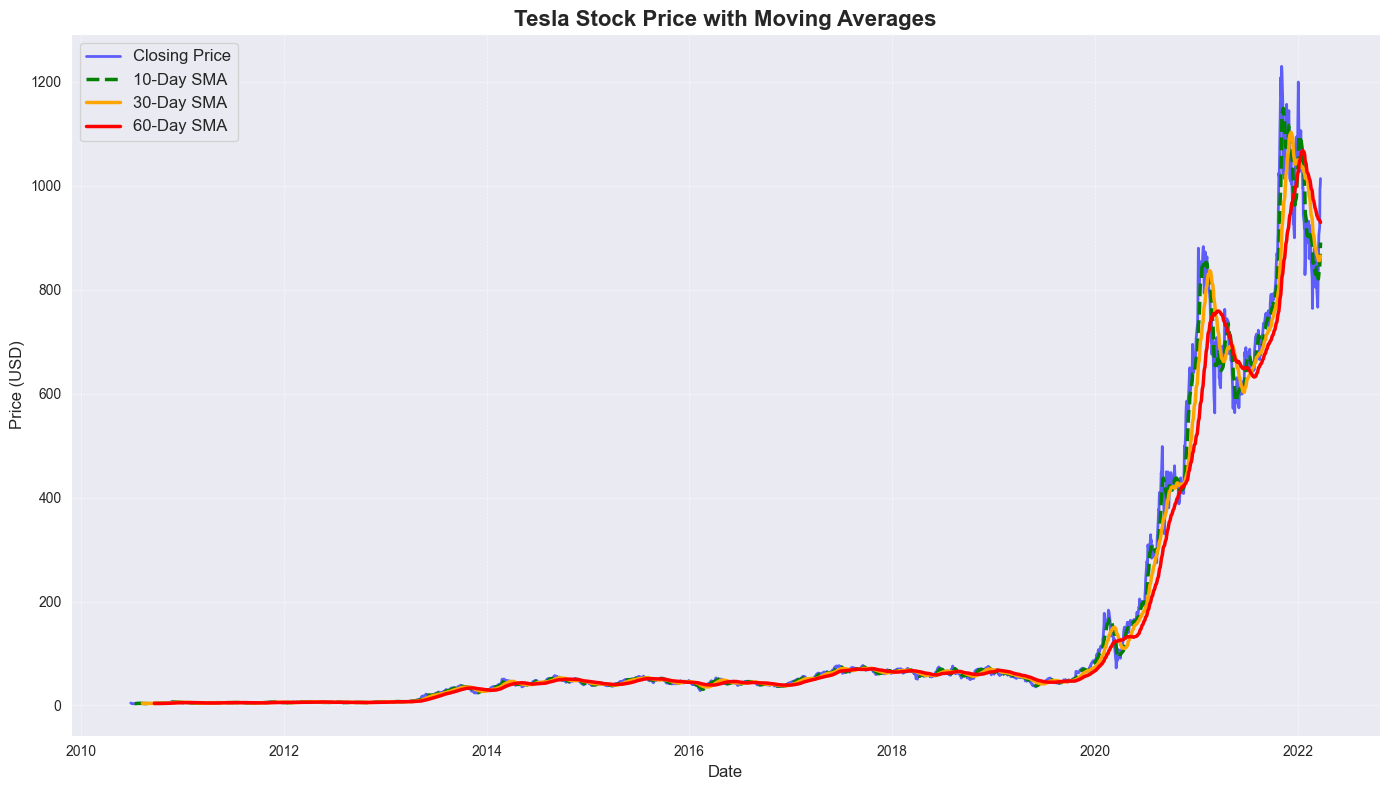

In [4]:
data['SMA_10'] = data['Close'].rolling(window=10).mean()
data['SMA_30'] = data['Close'].rolling(window=30).mean()
data['SMA_60'] = data['Close'].rolling(window=60).mean()

plt.figure(figsize=(14, 8))
plt.plot(data.index, data['Close'], label='Closing Price', color='blue', alpha=0.6, linewidth=2)

plt.plot(data.index, data['SMA_10'], label='10-Day SMA', color='green', linestyle='--', linewidth=2.5)
plt.plot(data.index, data['SMA_30'], label='30-Day SMA', color='orange', linestyle='-', linewidth=2.5)
plt.plot(data.index, data['SMA_60'], label='60-Day SMA', color='red', linestyle='-', linewidth=2.5)

plt.title('Tesla Stock Price with Moving Averages', fontsize=16, weight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)

plt.legend(loc='best', fontsize=12)

plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.show()

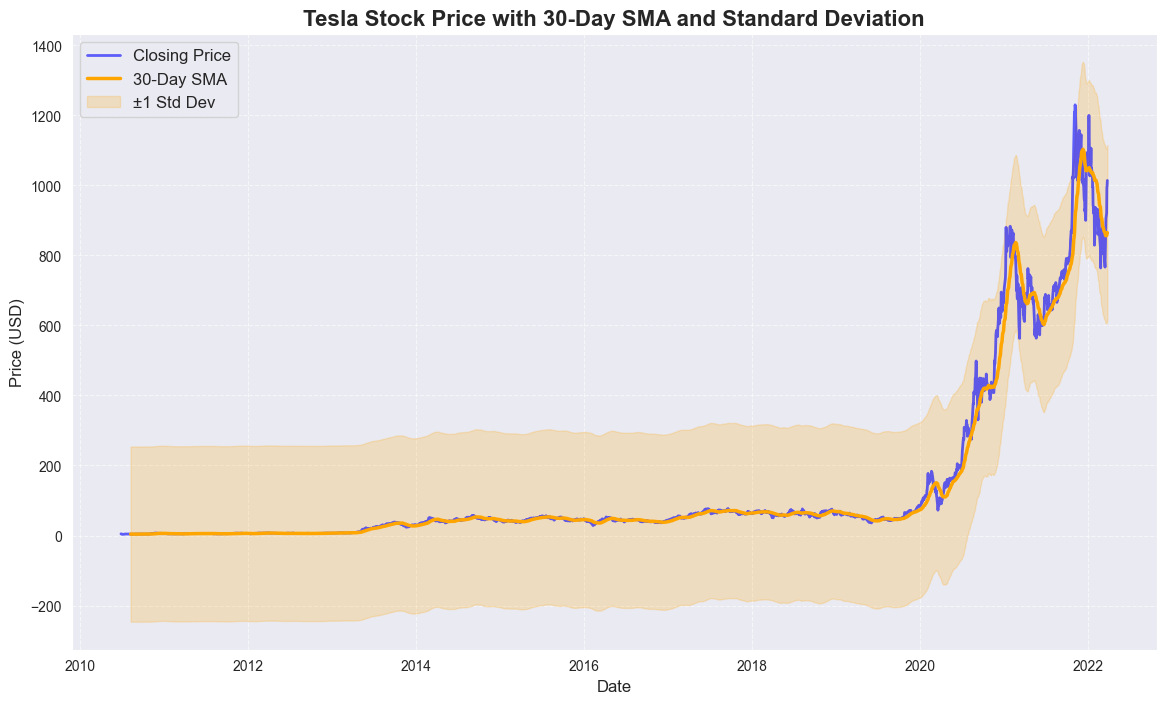

In [5]:
plt.figure(figsize=(14, 8))

plt.plot(data.index, data['Close'], label='Closing Price', color='blue', alpha=0.6, linewidth=2)

plt.plot(data.index, data['SMA_30'], label='30-Day SMA', color='orange', linestyle='-', linewidth=2.5)

plt.fill_between(data.index, data['SMA_30'] - data['Close'].std(), data['SMA_30'] + data['Close'].std(), color='orange', alpha=0.2, label='±1 Std Dev')

plt.title('Tesla Stock Price with 30-Day SMA and Standard Deviation', fontsize=16, weight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)

plt.legend(loc='best', fontsize=12)

plt.legend(loc='best', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)

plt.show()